# Keras Transformer forecast with VIX price features

This notebook replicates the baseline Transformer workflow, then adds leakage-safe shifted VIX close-price features to help the encoder condition log-return forecasts on the VIX level.


In [15]:
import random

import numpy as np
import pandas as pd
try:
    import yahooquery as yq
except ImportError:
    yq = None

try:
    import yfinance as yf
except ImportError:
    yf = None

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.21.0


## Load and Prep Data

This follows the baseline notebook data workflow with daily VIX, SPX, and GPR data. This variant adds leakage-safe VIX close-price features so the sequence model can condition return forecasts on the VIX level.


In [16]:
# Reddit sentiment is intentionally excluded from this model version.
# This keeps the modeling window driven by VIX, S&P 500, and GPR availability instead of Reddit history.


In [17]:
# https://www.matteoiacoviello.com/gpr.htm
# GPRD - Daily GPR (Index: 1985:2019=100)
# GPRD_ACT - Daily GPR Acts (Index: 1985:2019=100)
# GPRD_THREAT - Daily GPR Threats (Index: 1985:2019=100)
gpr_df = pd.read_stata("../data/gpr_daily.dta", columns=["date", "GPRD", "GPRD_ACT", "GPRD_THREAT"])
gpr_df["date"] = pd.to_datetime(gpr_df["date"])
gpr_df.head()


,date,GPRD,GPRD_ACT,GPRD_THREAT
0,1985-01-01,230.039429,275.197601,153.027985
1,1985-01-02,115.676971,146.772064,87.444572
2,1985-01-03,97.428459,158.937653,29.459934
3,1985-01-04,157.366638,156.882248,157.026352
4,1985-01-05,81.361313,92.698143,77.319405


In [18]:
MARKET_START = "1993-01-01"
MARKET_END = "2026-01-01"  # Set to None to pull the latest available market data.


def normalize_dates(values):
    dates = pd.to_datetime(values)
    if getattr(dates.dt, "tz", None) is not None:
        dates = dates.dt.tz_localize(None)
    return dates


def flatten_yahoo_columns(frame):
    out = frame.copy()
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = [str(col[0]).lower().replace(" ", "") for col in out.columns]
    else:
        out.columns = [str(col).lower().replace(" ", "") for col in out.columns]
    return out


def effective_market_end(end=MARKET_END):
    if end is not None:
        return end
    return (pd.Timestamp.today().normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def load_yahoo_adjclose(symbol, yf_symbol=None, start=MARKET_START, end=MARKET_END):
    end = effective_market_end(end)
    if yq is not None:
        try:
            hist = yq.Ticker(symbol).history(interval="1d", start=start, end=end).reset_index()
            if not hist.empty and "adjclose" in hist.columns:
                hist["date"] = normalize_dates(hist["date"])
                return hist[["date", "adjclose"]].copy()
        except Exception as exc:
            print(f"yahooquery failed for {symbol}; trying yfinance fallback. Error: {exc}")

    if yf is None:
        raise ImportError("Install yahooquery or yfinance to download market history.")

    download_symbol = yf_symbol or symbol
    hist = yf.download(download_symbol, start=start, end=end, progress=False, auto_adjust=False).reset_index()
    hist = flatten_yahoo_columns(hist)
    if "adjclose" not in hist.columns:
        raise ValueError(f"No adjusted-close column returned for {download_symbol}.")
    hist["date"] = normalize_dates(hist["date"])
    return hist[["date", "adjclose"]].copy()


vix = load_yahoo_adjclose("^VIX").rename(columns={"adjclose": "vix_adjclose"})
spx = load_yahoo_adjclose("^SPX", yf_symbol="^GSPC").rename(columns={"adjclose": "spx_adjclose"})

vix.head()


,date,vix_adjclose
0,1993-01-04,13.36
1,1993-01-05,13.35
2,1993-01-06,13.37
3,1993-01-07,14.72
4,1993-01-08,13.77


In [19]:
def load_and_merge_data():
    merged = (
        vix
        .merge(gpr_df, on="date", how="left")
        .merge(spx, on="date", how="left")
        .dropna()
    )

    merged = merged.sort_values("date").reset_index(drop=True)
    merged["vix_log_return"] = np.log(merged["vix_adjclose"]).diff()
    merged["spx_log_return"] = np.log(merged["spx_adjclose"]).diff()
    return merged.dropna().reset_index(drop=True)


df = load_and_merge_data()
print(f"Rows available: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Rows available: 8,306
Date range: 1993-01-05 to 2025-12-31


,date,vix_adjclose,GPRD,GPRD_ACT,GPRD_THREAT,spx_adjclose,vix_log_return,spx_log_return
0,1993-01-05,13.35,119.930664,82.456215,144.430908,434.339996,-0.000749,-0.002392
1,1993-01-06,13.37,84.319908,64.045990,106.841362,434.519989,0.001497,0.000414
2,1993-01-07,14.72,154.156281,71.479904,214.636658,430.730011,0.096194,-0.008760
3,1993-01-08,13.77,131.085571,105.958435,153.191666,429.049988,-0.066715,-0.003908
4,1993-01-11,12.86,149.133331,108.126747,180.376770,430.950012,-0.068371,0.004419


## Sequence Features

The Transformer with VIX price predicts one trading day at a time. This variant keeps the baseline shifted GPR/SPX/return features and adds VIX close-price features that are shifted or rolled-and-shifted by one row, so the model only sees VIX price information available before the close being predicted.


In [20]:
TARGET_COL = "vix_log_return"
LAG_COLS = ["GPRD_THREAT", "GPRD_ACT", "GPRD", "spx_log_return", "vix_adjclose"]
DEFAULT_ROLLING_WINDOWS = [21, 42, 365, 21, 42, 365, 21, 42, 365]
DEFAULT_ROLLING_SHIFTS = [1, 1, 1, 1, 1, 1, 1, 1, 1]
DEFAULT_ROLLING_STATS = [
    "mean",
    "mean",
    "mean",
    "mean",
    "mean",
    "mean",
    "std",
    "std",
    "std",
]
DEFAULT_ROLLING_TARGET_COLS = [
    "vix_log_return",
    "vix_log_return",
    "vix_log_return",
    "vix_adjclose",
    "vix_adjclose",
    "vix_adjclose",
    "vix_adjclose",
    "vix_adjclose",
    "vix_adjclose",
]
AR_ORDER = 1
USE_AR_FEATURES = True


def add_lagged_exo_features(dataframe) -> pd.DataFrame:
    """Shift exogenous and VIX price features back one trading period, as in arima-presentation.ipynb."""
    dataframe = dataframe.copy()
    for col in LAG_COLS:
        dataframe[f"{col.lower()}_shifted"] = dataframe[col].shift(1)
    return dataframe


def add_rolling_stats(
    frame: pd.DataFrame,
    windows: list[int],
    shifts: list[int],
    target_col: str | list[str] = "vix_log_return",
    stat: str | list[str] = "mean",
) -> pd.DataFrame:
    supported_stats = {"mean", "std", "min", "max"}

    if len(windows) != len(shifts):
        raise ValueError(f"`windows` and `shifts` must have the same length, got {len(windows)} and {len(shifts)}.")

    if isinstance(stat, str):
        if stat not in supported_stats:
            raise ValueError(f"Unsupported stat {stat!r}. Choose from {supported_stats}.")
        stats = [stat] * len(windows)
    else:
        if len(stat) != len(windows):
            raise ValueError(f"`stat` list must match length of `windows`, got {len(stat)} and {len(windows)}.")
        unsupported = set(stat) - supported_stats
        if unsupported:
            raise ValueError(f"Unsupported stats {unsupported}. Choose from {supported_stats}.")
        stats = list(stat)

    if isinstance(target_col, str):
        target_cols = [target_col] * len(windows)
    else:
        if len(target_col) != len(windows):
            raise ValueError(
                f"`target_col` list must match length of `windows`, got {len(target_col)} and {len(windows)}."
            )
        target_cols = list(target_col)

    missing = set(target_cols) - set(frame.columns)
    if missing:
        raise ValueError(f"Columns {missing} not found in frame.columns.")

    frame = frame.copy()
    for window, shift, s, col in zip(windows, shifts, stats, target_cols):
        rolled = frame[col].rolling(window=window, min_periods=window)
        series = getattr(rolled, s)()
        frame[f"{col}_{window}d_{s}_{shift}_shifted"] = series.shift(shift)

    return frame


def add_special_features(dataframe):
    dataframe = dataframe.copy()
    dataframe["days_since_last_trade"] = dataframe["date"].diff().dt.days.shift(1)
    return dataframe


def add_autoregressive_features(dataframe, p):
    dataframe = dataframe.copy()
    for i in range(p):
        dataframe[f"vix_log_return_shift_{i + 1}"] = dataframe["vix_log_return"].shift(i + 1)
    return dataframe


def build_modeling_frame(
    frame,
    windows=None,
    shifts=None,
    stats=None,
    target_cols=None,
    use_ar=USE_AR_FEATURES,
):
    full_df = frame.copy().reset_index(drop=True)
    if "_source_index" not in full_df.columns:
        full_df["_source_index"] = np.arange(len(full_df))

    full_df = add_lagged_exo_features(full_df)
    if use_ar:
        full_df = add_autoregressive_features(full_df, AR_ORDER)

    full_df = add_rolling_stats(
        full_df,
        windows=windows if windows is not None else DEFAULT_ROLLING_WINDOWS,
        shifts=shifts if shifts is not None else DEFAULT_ROLLING_SHIFTS,
        stat=stats if stats is not None else DEFAULT_ROLLING_STATS,
        target_col=target_cols if target_cols is not None else DEFAULT_ROLLING_TARGET_COLS,
    )
    full_df = add_special_features(full_df)
    full_df = full_df.dropna().reset_index(drop=True)

    feature_cols = [col for col in full_df.columns if col.endswith("_shifted")]
    if use_ar:
        feature_cols.extend([f"vix_log_return_shift_{i + 1}" for i in range(AR_ORDER)])

    return full_df, feature_cols


model_df, FEATURE_COLS = build_modeling_frame(df)
VIX_PRICE_FEATURE_COLS = [col for col in FEATURE_COLS if col.startswith("vix_adjclose")]

print(f"Rows available for Transformer with VIX price: {len(model_df):,}")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}")
print(f"Feature count: {len(FEATURE_COLS)}")
print(f"VIX price feature count: {len(VIX_PRICE_FEATURE_COLS)}")
model_df[["date", TARGET_COL, *FEATURE_COLS]].head()


Rows available for Transformer with VIX price: 7,941
Date range: 1994-06-15 to 2025-12-31
Feature count: 15
VIX price feature count: 7


,date,vix_log_return,gprd_threat_shifted,gprd_act_shifted,gprd_shifted,spx_log_return_shifted,vix_adjclose_shifted,vix_log_return_21d_mean_1_shifted,vix_log_return_42d_mean_1_shifted,vix_log_return_365d_mean_1_shifted,vix_adjclose_21d_mean_1_shifted,vix_adjclose_42d_mean_1_shifted,vix_adjclose_365d_mean_1_shifted,vix_adjclose_21d_std_1_shifted,vix_adjclose_42d_std_1_shifted,vix_adjclose_365d_std_1_shifted,vix_log_return_shift_1
0,1994-06-15,-0.006920,146.418808,146.284454,132.062500,0.007097,11.60,-0.010757,-0.009128,-0.000387,12.835714,13.998095,13.079425,0.686029,1.478751,1.770981,-0.027213
1,1994-06-16,-0.026387,215.677032,110.817825,159.329315,-0.003814,11.52,-0.011510,-0.008220,-0.000404,12.685714,13.885000,13.074411,0.604430,1.482393,1.772802,-0.006920
2,1994-06-17,0.092714,161.396713,51.599552,122.927315,0.002862,11.22,-0.010812,-0.008420,-0.000480,12.549524,13.771667,13.068521,0.596720,1.500169,1.775387,-0.026387
3,1994-06-20,0.125784,177.530960,33.256508,120.093086,-0.007562,12.31,-0.000919,-0.007992,-0.000490,12.538095,13.654762,13.061918,0.599004,1.413715,1.773709,0.092714
4,1994-06-21,0.051651,211.360443,81.741867,163.988495,-0.006499,13.96,0.005912,-0.004593,0.000038,12.615714,13.584048,13.062438,0.671867,1.316853,1.773946,0.125784


## Keras Dataset and Transformer Model


In [21]:
LOOKBACK_DAYS = 20
BATCH_SIZE = 32
MODEL_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_TRANSFORMER_BLOCKS = 2
DROPOUT = 0.1
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 75
PATIENCE = 10

N_SPLITS = 4
TEST_SIZE = 242
VALIDATION_SIZE = 242

MODEL_NAME = "keras_transformer_vix_price"
MODEL_LABEL = "Keras Transformer with VIX price"


In [22]:
def eligible_target_indices(indices, lookback_days):
    return [int(idx) for idx in indices if int(idx) >= lookback_days - 1]


def split_train_validation(train_target_indices, validation_size=VALIDATION_SIZE):
    train_target_indices = list(train_target_indices)
    if len(train_target_indices) <= validation_size + 1:
        validation_size = max(1, len(train_target_indices) // 5)
    return train_target_indices[:-validation_size], train_target_indices[-validation_size:]


def build_sequence_arrays(frame, target_indices, feature_cols, target_col, feature_scaler, target_scaler, lookback_days):
    raw_features = frame[feature_cols].astype(np.float32)
    raw_targets = frame[[target_col]].astype(np.float32)
    features = feature_scaler.transform(raw_features).astype(np.float32)
    targets_scaled = target_scaler.transform(raw_targets).reshape(-1).astype(np.float32)
    targets_raw = raw_targets.to_numpy(dtype=np.float32).reshape(-1)

    x, y, y_raw, kept_indices = [], [], [], []
    for target_idx in target_indices:
        target_idx = int(target_idx)
        start_idx = target_idx - lookback_days + 1
        if start_idx < 0:
            continue
        x.append(features[start_idx:target_idx + 1])
        y.append(targets_scaled[target_idx])
        y_raw.append(targets_raw[target_idx])
        kept_indices.append(target_idx)

    return (
        np.asarray(x, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(y_raw, dtype=np.float32),
        np.asarray(kept_indices, dtype=int),
    )


def make_arrays_for_fold(train_idx, test_idx):
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)
    full_idx = np.concatenate([train_idx, test_idx])

    fold_source_df = df.iloc[full_idx].copy()
    fold_source_df["_source_index"] = full_idx
    fold_model_df, feature_cols = build_modeling_frame(fold_source_df)

    train_target_indices = np.flatnonzero(fold_model_df["_source_index"].isin(train_idx)).astype(int)
    test_target_indices = np.flatnonzero(fold_model_df["_source_index"].isin(test_idx)).astype(int)
    train_target_indices = eligible_target_indices(train_target_indices, LOOKBACK_DAYS)
    test_target_indices = eligible_target_indices(test_target_indices, LOOKBACK_DAYS)
    fit_target_indices, val_target_indices = split_train_validation(train_target_indices)

    if not fit_target_indices or not val_target_indices or not test_target_indices:
        raise ValueError("Fold does not have enough rows after feature engineering for train/validation/test sequences.")

    scaler_fit_idx = np.arange(max(fit_target_indices) + 1)
    feature_scaler = StandardScaler().fit(fold_model_df.iloc[scaler_fit_idx][feature_cols])
    target_scaler = StandardScaler().fit(fold_model_df.iloc[fit_target_indices][[TARGET_COL]])

    train_arrays = build_sequence_arrays(
        fold_model_df, fit_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    val_arrays = build_sequence_arrays(
        fold_model_df, val_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    test_arrays = build_sequence_arrays(
        fold_model_df, test_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    fold_indices = {
        "fit_target_indices": np.asarray(fit_target_indices, dtype=int),
        "val_target_indices": np.asarray(val_target_indices, dtype=int),
        "test_target_indices": np.asarray(test_target_indices, dtype=int),
        "scaler_fit_indices": np.asarray(scaler_fit_idx, dtype=int),
    }
    return train_arrays, val_arrays, test_arrays, target_scaler, fold_indices, fold_model_df, feature_cols


class NumericTokenAndPositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, model_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.model_dim = model_dim
        self.value_projection = layers.Dense(model_dim)
        self.position_embedding = layers.Embedding(input_dim=sequence_length, output_dim=model_dim)

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        return self.value_projection(inputs) + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "model_dim": self.model_dim})
        return config


def build_keras_transformer(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = NumericTokenAndPositionEmbedding(
        sequence_length=input_shape[0],
        model_dim=MODEL_DIM,
        name="token_position_embedding",
    )(inputs)

    for block_idx in range(NUM_TRANSFORMER_BLOCKS):
        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=MODEL_DIM // NUM_HEADS,
            dropout=DROPOUT,
            name=f"self_attention_{block_idx + 1}",
        )(x, x)
        attention_output = layers.Dropout(DROPOUT)(attention_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

        ffn_output = layers.Dense(FF_DIM, activation="gelu")(x)
        ffn_output = layers.Dropout(DROPOUT)(ffn_output)
        ffn_output = layers.Dense(MODEL_DIM)(ffn_output)
        ffn_output = layers.Dropout(DROPOUT)(ffn_output)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    x = layers.GlobalAveragePooling1D(name="sequence_pooling")(x)
    x = layers.Dense(MODEL_DIM // 2, activation="gelu")(x)
    x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(1)(x)

    try:
        optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss="mse")
    return model


def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=np.float64)
    predicted = np.asarray(predicted, dtype=np.float64)
    actual_rise = (actual > 0).astype(int)
    predicted_rise = (predicted > 0).astype(int)
    mse = mean_squared_error(actual, predicted)
    metrics = {
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
        "swing_accuracy": float(accuracy_score(actual_rise, predicted_rise)),
        "directional_accuracy": float(accuracy_score(actual_rise, predicted_rise)),
    }
    if len(np.unique(actual_rise)) > 1:
        metrics["swing_balanced_accuracy"] = float(balanced_accuracy_score(actual_rise, predicted_rise))
    else:
        metrics["swing_balanced_accuracy"] = np.nan
    return metrics


def evaluate_predictions(frame, pred_scaled, y_raw, target_indices, target_scaler):
    pred_raw = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    source_indices = frame.iloc[target_indices]["_source_index"].to_numpy(dtype=int)
    out = pd.DataFrame({
        "target_index": source_indices,
        "fold_row_index": target_indices,
        "date": frame.iloc[target_indices]["date"].to_numpy(),
        "actual": y_raw,
        "predicted": pred_raw,
    })
    metrics = regression_metrics(out["actual"], out["predicted"])
    return metrics, out


## Walk-Forward Evaluation

This uses the same four-fold, 242-trading-day `TimeSeriesSplit` setup as `arima-presentation.ipynb`. The scaler is fit on each fold's training rows only; test sequences may use prior observed returns through yesterday, matching a one-day-ahead walk-forward forecast.


Epoch 1/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 1.0370 - val_loss: 1.5309
Epoch 2/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.0041 - val_loss: 1.5283
Epoch 3/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.0018 - val_loss: 1.5258
Epoch 4/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.9994 - val_loss: 1.5200
Epoch 5/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9981 - val_loss: 1.5144
Epoch 6/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.9960 - val_loss: 1.5006
Epoch 7/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9961 - val_loss: 1.5049
Epoch 8/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.9936 - val_loss: 1.4923
Epoch 9/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9933 - val_loss: 1.4855
Epoch 10/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.9924 - val_loss: 1.4874
Epoch 11/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.9886 - val_loss: 1.4863
Epoch 12/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 

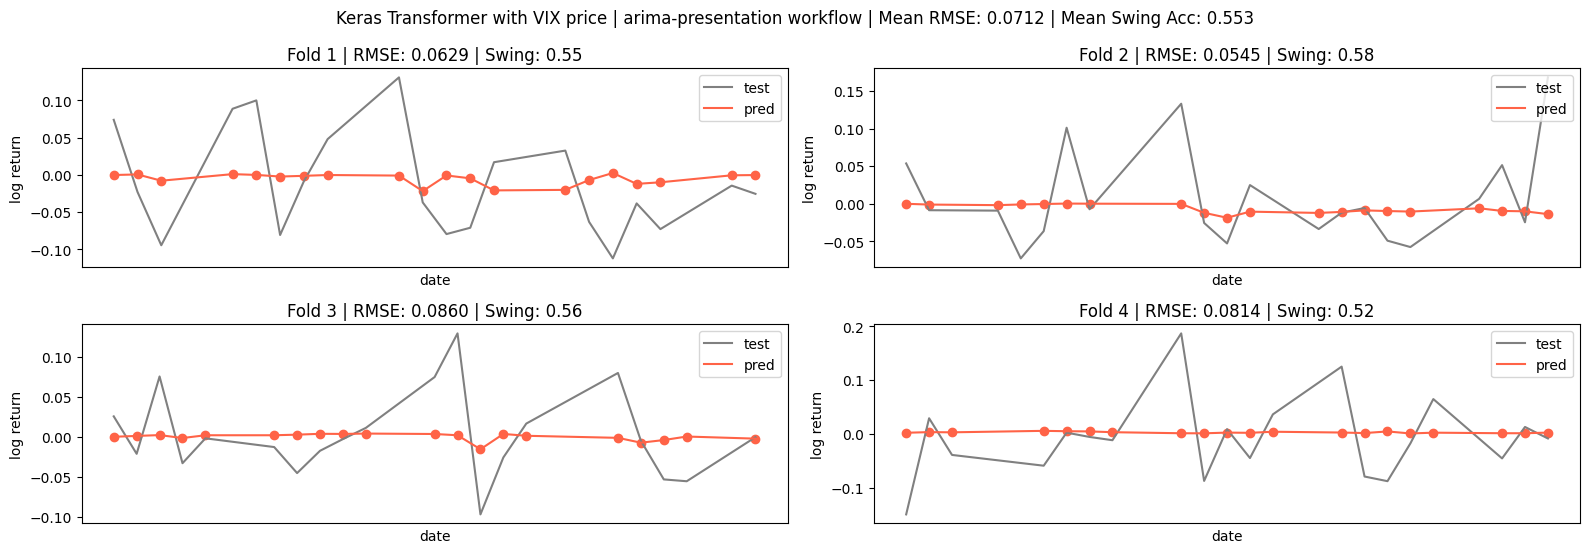

mse: 0.005240645276536126
rmse: 0.07122532348809847
accuracy: 0.5526859504132231
balanced_accuracy: 0.5577074535982203


,model,mean_mse,mean_rmse,mean_mae,mean_r2,mean_swing_accuracy,mean_swing_balanced_accuracy
0,keras_transformer_vix_price,0.005241,0.071225,0.049665,0.015611,0.552686,0.557707
3,zero_return,0.005392,0.072054,0.050702,-0.000483,0.568182,0.500000
2,train_mean,0.005392,0.072055,0.050711,-0.000528,0.458678,0.500000
1,previous_vix_return,0.011322,0.104432,0.074572,-1.104032,0.473140,0.462750


,fold,model,epochs,mse,rmse,mae,r2,swing_accuracy,directional_accuracy,swing_balanced_accuracy
0,1,keras_transformer_vix_price,26.0,0.003959,0.062920,0.047043,-0.040833,0.545455,0.545455,0.543901
1,1,zero_return,NaN,0.003806,0.061694,0.047499,-0.000661,0.590909,0.590909,0.500000
2,1,train_mean,NaN,0.003806,0.061696,0.047514,-0.000735,0.409091,0.409091,0.500000
3,1,previous_vix_return,NaN,0.008104,0.090023,0.067457,-1.130637,0.471074,0.471074,0.452991
4,2,keras_transformer_vix_price,19.0,0.002974,0.054536,0.041421,0.000282,0.582645,0.582645,0.567286
5,2,zero_return,NaN,0.002978,0.054568,0.041977,-0.000883,0.561983,0.561983,0.500000
6,2,train_mean,NaN,0.002978,0.054571,0.041991,-0.001007,0.438017,0.438017,0.500000
7,2,previous_vix_return,NaN,0.006230,0.078933,0.060325,-1.094256,0.508264,0.508264,0.501110
8,3,keras_transformer_vix_price,22.0,0.007399,0.086016,0.053546,0.014951,0.561983,0.561983,0.568648
9,3,zero_return,NaN,0.007513,0.086678,0.054307,-0.000269,0.566116,0.566116,0.500000


In [23]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
fold_splits = list(tscv.split(df))
n_folds = len(fold_splits)
plot_cols = min(2, max(1, n_folds))
plot_rows = int(np.ceil(n_folds / plot_cols))

fold_metrics = []
fold_predictions = []
fold_histories = []
fold_target_summaries = []
fig, axes = plt.subplots(
    nrows=plot_rows,
    ncols=plot_cols,
    figsize=(8 * plot_cols, 2.8 * plot_rows),
    squeeze=False,
)
axes = axes.ravel()

for fold, (train_idx, test_idx) in enumerate(fold_splits):
    (
        train_arrays,
        val_arrays,
        test_arrays,
        target_scaler,
        fold_indices,
        fold_model_df,
        fold_feature_cols,
    ) = make_arrays_for_fold(train_idx, test_idx)
    x_train, y_train, _, _ = train_arrays
    x_val, y_val, _, _ = val_arrays
    x_test, _, y_test_raw, test_target_indices = test_arrays

    for split_name, indices in [
        ("train", fold_indices["fit_target_indices"]),
        ("validation", fold_indices["val_target_indices"]),
        ("test", fold_indices["test_target_indices"]),
    ]:
        values = fold_model_df.iloc[indices][TARGET_COL].to_numpy(dtype=np.float64)
        fold_target_summaries.append({
            "fold": fold + 1,
            "split": split_name,
            "rows": len(values),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        })

    keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED + fold)
    model = build_keras_transformer(input_shape=(LOOKBACK_DAYS, len(fold_feature_cols)))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            min_delta=1e-5,
            restore_best_weights=True,
        )
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )
    fold_history = pd.DataFrame({
        "fold": fold + 1,
        "epoch": np.arange(1, len(history.history["loss"]) + 1),
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
    })
    fold_histories.append(fold_history)

    pred_scaled = model.predict(x_test, verbose=0).reshape(-1)
    test_metrics, preds = evaluate_predictions(fold_model_df, pred_scaled, y_test_raw, test_target_indices, target_scaler)
    preds["fold"] = fold + 1
    fold_predictions.append(preds)
    fold_metrics.append({"fold": fold + 1, "model": MODEL_NAME, "epochs": len(history.history["loss"]), **test_metrics})

    train_target_values = fold_model_df.iloc[fold_indices["fit_target_indices"]][TARGET_COL].to_numpy(dtype=np.float64)
    baseline_predictions = {
        "zero_return": np.zeros_like(y_test_raw, dtype=np.float64),
        "train_mean": np.full_like(y_test_raw, train_target_values.mean(), dtype=np.float64),
        "previous_vix_return": fold_model_df[TARGET_COL].shift(1).iloc[test_target_indices].to_numpy(dtype=np.float64),
    }
    for baseline_name, baseline_pred in baseline_predictions.items():
        fold_metrics.append({
            "fold": fold + 1,
            "model": baseline_name,
            "epochs": np.nan,
            **regression_metrics(y_test_raw, baseline_pred),
        })

    ax = axes[fold]
    display_n = min(20, len(preds))
    ax.plot(preds["date"].iloc[:display_n], preds["actual"].iloc[:display_n], color="grey", label="test")
    ax.plot(preds["date"].iloc[:display_n], preds["predicted"].iloc[:display_n], color="tomato", label="pred")
    ax.scatter(preds["date"].iloc[:display_n], preds["predicted"].iloc[:display_n], marker="o", color="tomato")
    ax.set_title(
        f"Fold {fold + 1} | RMSE: {test_metrics['rmse']:.4f} | Swing: {test_metrics['swing_accuracy']:.2f}"
    )
    ax.set_xlabel("date")
    ax.set_ylabel("log return")
    ax.set_xticks([])
    ax.legend(loc="upper right")

for ax in axes[n_folds:]:
    ax.set_visible(False)

metrics_df = pd.DataFrame(fold_metrics)
predictions_df = pd.concat(fold_predictions, ignore_index=True)
history_df = pd.concat(fold_histories, ignore_index=True)
target_summary_df = pd.DataFrame(fold_target_summaries)

mean_transformer_rmse = metrics_df.loc[metrics_df["model"].eq(MODEL_NAME), "rmse"].mean()
mean_transformer_swing_accuracy = metrics_df.loc[metrics_df["model"].eq(MODEL_NAME), "swing_accuracy"].mean()
mean_transformer_balanced_swing_accuracy = metrics_df.loc[metrics_df["model"].eq(MODEL_NAME), "swing_balanced_accuracy"].mean()

plt.suptitle(
    f"{MODEL_LABEL} | arima-presentation workflow | "
    f"Mean RMSE: {mean_transformer_rmse:.4f} | "
    f"Mean Swing Acc: {mean_transformer_swing_accuracy:.3f}"
)
plt.tight_layout()
plt.show()

model_summary = (
    metrics_df.groupby("model", as_index=False)
    .agg(
        mean_mse=("mse", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_r2=("r2", "mean"),
        mean_swing_accuracy=("swing_accuracy", "mean"),
        mean_swing_balanced_accuracy=("swing_balanced_accuracy", "mean"),
    )
    .sort_values("mean_rmse")
)

print(f"mse: {metrics_df.loc[metrics_df['model'].eq(MODEL_NAME), 'mse'].mean()}")
print(f"rmse: {mean_transformer_rmse}")
print(f"accuracy: {mean_transformer_swing_accuracy}")
print(f"balanced_accuracy: {mean_transformer_balanced_swing_accuracy}")
display(model_summary)
metrics_df


## Fold Test Prediction Plots

This repeats the four-fold test prediction view used in `arima-presentation.ipynb`, using the held-out predictions saved by the walk-forward evaluation cell.


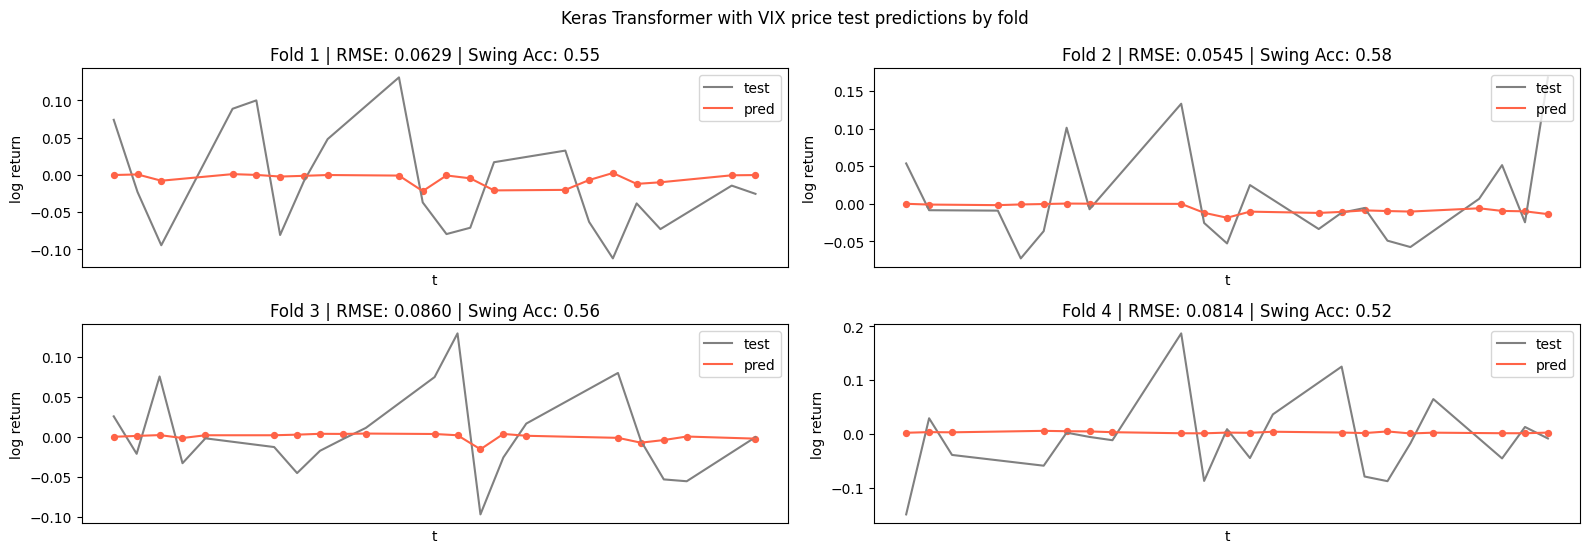

In [24]:
if "predictions_df" not in globals() or "metrics_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so predictions_df and metrics_df are available.")

PLOT_FIRST_N_TEST_DAYS = 20
fold_ids = sorted(predictions_df["fold"].unique())
plot_cols = min(2, max(1, len(fold_ids)))
plot_rows = int(np.ceil(len(fold_ids) / plot_cols))

fig, axes = plt.subplots(
    nrows=plot_rows,
    ncols=plot_cols,
    figsize=(8 * plot_cols, 2.8 * plot_rows),
    squeeze=False,
)
axes = axes.ravel()

for ax, fold_id in zip(axes, fold_ids):
    fold_preds = predictions_df[predictions_df["fold"].eq(fold_id)].sort_values("date")
    if PLOT_FIRST_N_TEST_DAYS is not None:
        fold_preds = fold_preds.head(PLOT_FIRST_N_TEST_DAYS)

    fold_metrics_row = metrics_df[
        metrics_df["fold"].eq(fold_id) & metrics_df["model"].eq(MODEL_NAME)
    ].iloc[0]

    ax.plot(fold_preds["date"], fold_preds["actual"], color="grey", label="test")
    ax.plot(fold_preds["date"], fold_preds["predicted"], color="tomato", label="pred")
    ax.scatter(fold_preds["date"], fold_preds["predicted"], marker="o", color="tomato", s=18)
    ax.set_title(
        f"Fold {fold_id} | RMSE: {fold_metrics_row['rmse']:.4f} | "
        f"Swing Acc: {fold_metrics_row['swing_accuracy']:.2f}"
    )
    ax.set_xlabel("t")
    ax.set_ylabel("log return")
    ax.set_xticks([])
    ax.legend(loc="upper right")

for ax in axes[len(fold_ids):]:
    ax.set_visible(False)

plt.suptitle(f"{MODEL_LABEL} test predictions by fold")
plt.tight_layout()
plt.show()


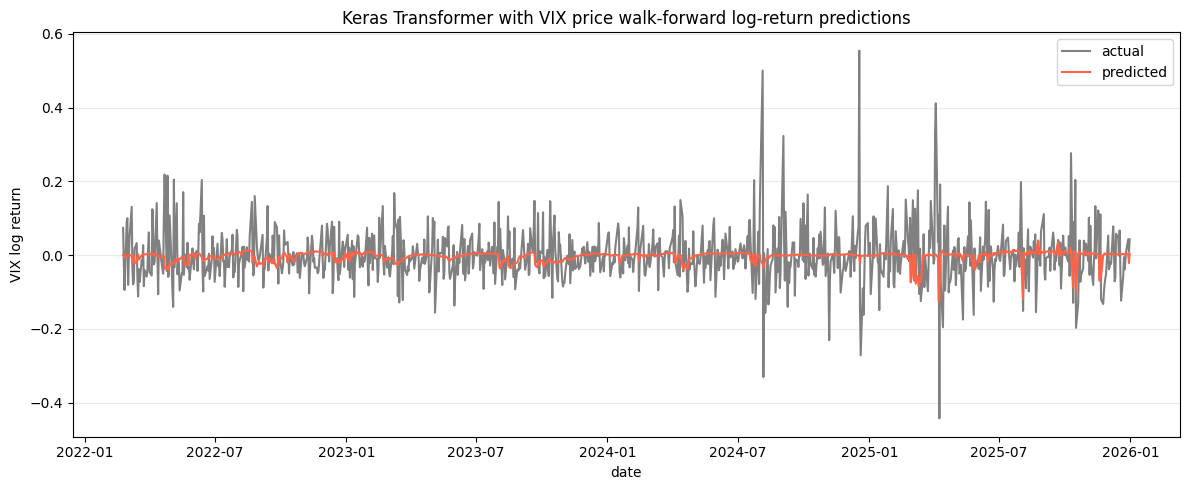

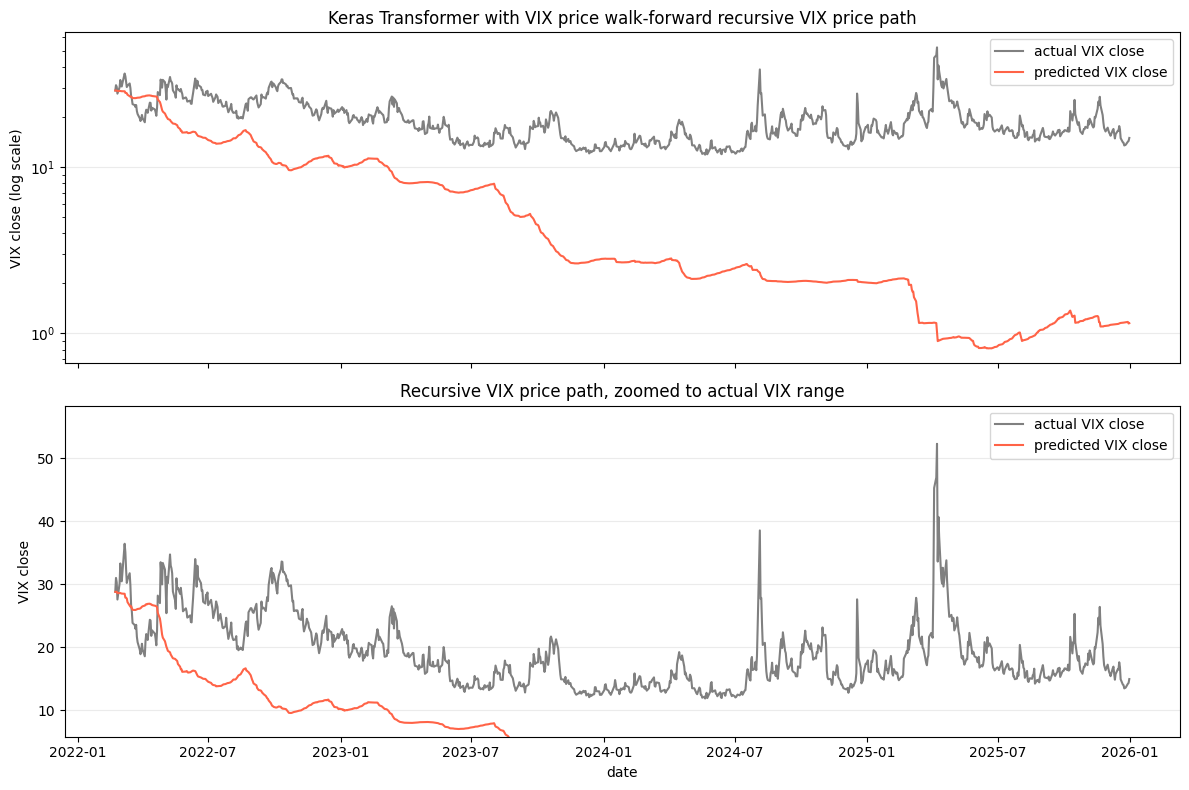

Keras Transformer with VIX price mean log-return RMSE: 0.0712
Keras Transformer with VIX price mean log-return MAE: 0.0497
Keras Transformer with VIX price recursive VIX price RMSE: 14.0567
Keras Transformer with VIX price recursive VIX price MAE: 13.0340
Keras Transformer with VIX price one-day anchored VIX price RMSE: 1.7234
Keras Transformer with VIX price one-day anchored VIX price MAE: 1.0191
Max actual price reconstruction error from one-day log returns: 0.00000365
Max actual price reconstruction error from cumulative log returns: 0.00000181


,date,actual_vix_price,predicted_vix_price,predicted_vix_price_one_day,actual_simple_return,predicted_simple_return,fold
0,2022-02-23,31.02,28.806108,28.806107,0.076710,-0.000135,1
1,2022-02-24,30.32,28.824465,31.039766,-0.022566,0.000637,1
2,2022-02-25,27.59,28.601167,30.085116,-0.090040,-0.007747,1
3,2022-02-28,30.15,28.631453,27.619216,0.092787,0.001059,1
4,2022-03-01,33.32,28.631540,30.150093,0.105141,0.000003,1


In [29]:
# Full walk-forward prediction plots, matching the RNN notebook.
if "predictions_df" not in globals() or "metrics_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so predictions_df and metrics_df are available.")

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=predictions_df, x="date", y="actual", label="actual", color="grey", ax=ax)
sns.lineplot(data=predictions_df, x="date", y="predicted", label="predicted", color="tomato", ax=ax)
ax.set_title(f"{MODEL_LABEL} walk-forward log-return predictions")
ax.set_xlabel("date")
ax.set_ylabel("VIX log return")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

required_price_cols = {"vix_adjclose"}
missing_price_cols = sorted(required_price_cols.difference(df.columns))
if missing_price_cols:
    raise ValueError(f"df is missing price columns needed for price reconstruction: {missing_price_cols}")

price_predictions_df = (
    predictions_df.copy()
    .sort_values(["target_index", "fold"])
    .drop_duplicates(subset=["target_index"], keep="last")
    .sort_values("target_index")
    .reset_index(drop=True)
)

target_positions = price_predictions_df["target_index"].to_numpy(dtype=int)
previous_target_positions = target_positions - 1
if len(target_positions) == 0:
    raise ValueError("predictions_df is empty; run the walk-forward evaluation cell first.")
if np.any(previous_target_positions < 0):
    raise ValueError("Cannot build price predictions without a prior VIX close for every target row.")

price_predictions_df["date"] = df.iloc[target_positions]["date"].to_numpy()
price_predictions_df["actual_vix_price"] = df.iloc[target_positions]["vix_adjclose"].to_numpy(dtype=np.float64)
price_predictions_df["previous_actual_vix_price"] = df.iloc[previous_target_positions]["vix_adjclose"].to_numpy(dtype=np.float64)
price_predictions_df["actual_simple_return"] = np.expm1(price_predictions_df["actual"])
price_predictions_df["predicted_simple_return"] = np.expm1(price_predictions_df["predicted"])
price_predictions_df["actual_vix_price_from_return"] = (
    price_predictions_df["previous_actual_vix_price"] * np.exp(price_predictions_df["actual"])
)
price_predictions_df["predicted_vix_price_one_day"] = (
    price_predictions_df["previous_actual_vix_price"] * np.exp(price_predictions_df["predicted"])
)

anchor_index = int(previous_target_positions[0])
anchor_row = df.iloc[anchor_index]
anchor_date = anchor_row["date"]
anchor_price = float(anchor_row["vix_adjclose"])

actual_path_prices = []
predicted_path_prices = []
previous_actual_path_price = anchor_price
previous_predicted_path_price = anchor_price
for actual_log_return, predicted_log_return in zip(
    price_predictions_df["actual"].to_numpy(dtype=np.float64),
    price_predictions_df["predicted"].to_numpy(dtype=np.float64),
):
    previous_actual_path_price = previous_actual_path_price * np.exp(actual_log_return)
    previous_predicted_path_price = previous_predicted_path_price * np.exp(predicted_log_return)
    actual_path_prices.append(previous_actual_path_price)
    predicted_path_prices.append(previous_predicted_path_price)

price_predictions_df["actual_vix_price_from_path"] = actual_path_prices
price_predictions_df["predicted_vix_price"] = predicted_path_prices

non_consecutive_targets = price_predictions_df["target_index"].diff().dropna().ne(1)
if non_consecutive_targets.any():
    print(
        "Warning: predicted target rows are not consecutive; "
        "the recursive price path compounds across available predicted rows."
    )

price_plot_df = pd.concat(
    [
        pd.DataFrame(
            {
                "date": [anchor_date],
                "actual_vix_price": [anchor_price],
                "predicted_vix_price": [anchor_price],
            }
        ),
        price_predictions_df[["date", "actual_vix_price", "predicted_vix_price"]],
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
for price_ax in axes:
    price_ax.plot(price_plot_df["date"], price_plot_df["actual_vix_price"], label="actual VIX close", color="grey")
    price_ax.plot(price_plot_df["date"], price_plot_df["predicted_vix_price"], label="predicted VIX close", color="tomato")
    price_ax.grid(True, axis="y", alpha=0.25)
    price_ax.legend()

axes[0].set_yscale("log")
axes[0].set_title(f"{MODEL_LABEL} walk-forward recursive VIX price path")
axes[0].set_ylabel("VIX close (log scale)")

actual_min = price_plot_df["actual_vix_price"].min()
actual_max = price_plot_df["actual_vix_price"].max()
actual_padding = max((actual_max - actual_min) * 0.15, 1.0)
axes[1].set_ylim(max(0, actual_min - actual_padding), actual_max + actual_padding)
axes[1].set_title("Recursive VIX price path, zoomed to actual VIX range")
axes[1].set_xlabel("date")
axes[1].set_ylabel("VIX close")
plt.tight_layout()
plt.show()

model_rows = metrics_df[metrics_df["model"].eq(MODEL_NAME)]
recursive_price_metrics = regression_metrics(
    price_predictions_df["actual_vix_price"],
    price_predictions_df["predicted_vix_price"],
)
one_day_price_metrics = regression_metrics(
    price_predictions_df["actual_vix_price"],
    price_predictions_df["predicted_vix_price_one_day"],
)
one_day_reconstruction_error = (
    price_predictions_df["actual_vix_price"] - price_predictions_df["actual_vix_price_from_return"]
).abs().max()
path_reconstruction_error = (
    price_predictions_df["actual_vix_price"] - price_predictions_df["actual_vix_price_from_path"]
).abs().max()
print(f"{MODEL_LABEL} mean log-return RMSE: {model_rows['rmse'].mean():.4f}")
print(f"{MODEL_LABEL} mean log-return MAE: {model_rows['mae'].mean():.4f}")
print(f"{MODEL_LABEL} recursive VIX price RMSE: {recursive_price_metrics['rmse']:.4f}")
print(f"{MODEL_LABEL} recursive VIX price MAE: {recursive_price_metrics['mae']:.4f}")
print(f"{MODEL_LABEL} one-day anchored VIX price RMSE: {one_day_price_metrics['rmse']:.4f}")
print(f"{MODEL_LABEL} one-day anchored VIX price MAE: {one_day_price_metrics['mae']:.4f}")
print(f"Max actual price reconstruction error from one-day log returns: {one_day_reconstruction_error:.8f}")
print(f"Max actual price reconstruction error from cumulative log returns: {path_reconstruction_error:.8f}")
price_predictions_df[
    [
        "date",
        "actual_vix_price",
        "predicted_vix_price",
        "predicted_vix_price_one_day",
        "actual_simple_return",
        "predicted_simple_return",
        "fold",
    ]
].head()


# Backtesting

This mirrors the baseline Transformer backtest, but the final model uses the added shifted VIX close-price features.

Open positions are finalized at the end of each backtest so trade counts, stats, and plotted trade markers include positions that are still open on the last bar.


In [25]:
from backtesting import Backtest, Strategy


class VixPredStrategy(Strategy):
    vix_rise_threshold = 0.015   # above this -> expect SPY weakness, close any long
    vix_fall_threshold = -0.015  # below this -> expect SPY strength, enter long

    def init(self):
        self.vix_pred = self.I(func=lambda: self.data.PredVixLogReturn, name="PredVixLogReturn")

    def next(self):
        pred = self.vix_pred[-1]

        if not self.position:
            if pred < self.vix_fall_threshold:
                self.buy()
        else:
            if pred > self.vix_rise_threshold:
                self.position.close()


def fetch_spx(start, end):
    if yq is not None:
        try:
            hist = yq.Ticker("SPY").history(start=start, end=end).reset_index()
            if not hist.empty:
                hist = flatten_yahoo_columns(hist)
                hist["date"] = normalize_dates(hist["date"])
                hist = hist.rename(columns={
                    "open": "Open",
                    "high": "High",
                    "low": "Low",
                    "close": "Close",
                    "volume": "Volume",
                })
                return hist.set_index("date")[["Open", "High", "Low", "Close", "Volume"]].dropna()
        except Exception as exc:
            print(f"yahooquery failed for SPY OHLCV; trying yfinance fallback. Error: {exc}")

    if yf is None:
        raise ImportError("Install yahooquery or yfinance to download SPY OHLCV data.")

    hist = yf.download("SPY", start=start, end=end, progress=False, auto_adjust=False).reset_index()
    hist = flatten_yahoo_columns(hist)
    hist["date"] = normalize_dates(hist["date"])
    hist = hist.rename(columns={
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
    })
    return hist.set_index("date")[["Open", "High", "Low", "Close", "Volume"]].dropna()


def attach_preds(spx_df, prediction_frame):
    dates = normalize_dates(pd.Series(prediction_frame["date"].values))
    pred_series = pd.Series(prediction_frame["predicted"].values, index=dates).shift(1)
    spx = spx_df[spx_df.index.isin(pred_series.index)].copy()
    spx["PredVixLogReturn"] = pred_series.reindex(spx.index)
    return spx.dropna()


def plot_backtest_equity(test_results, validation_results, model_label):
    fig, ax = plt.subplots(figsize=(10, 4))
    test_equity = test_results["_equity_curve"]["Equity"]
    validation_equity = validation_results["_equity_curve"]["Equity"]
    test_equity.plot(ax=ax, label="2023 threshold-tuning period", color="steelblue")
    validation_equity.plot(ax=ax, label="2024 validation period", color="tomato")

    def nearest_equity_point(equity, timestamp):
        if equity.empty or pd.isna(timestamp):
            return None
        index = pd.DatetimeIndex(equity.index)
        loc = index.get_indexer([pd.Timestamp(timestamp)], method="nearest")[0]
        if loc < 0:
            return None
        return equity.index[loc], float(equity.iloc[loc])

    def add_trade_markers(results, equity, color, label_prefix):
        trades = results.get("_trades", pd.DataFrame())
        if trades is None or len(trades) == 0:
            return

        entry_labeled = False
        exit_labeled = False
        span_labeled = False
        for _, trade in trades.iterrows():
            entry_point = nearest_equity_point(equity, trade.get("EntryTime"))
            exit_point = nearest_equity_point(equity, trade.get("ExitTime"))

            if entry_point is not None and exit_point is not None:
                ax.axvspan(
                    entry_point[0],
                    exit_point[0],
                    color=color,
                    alpha=0.08,
                    label=f"{label_prefix} holding period" if not span_labeled else None,
                )
                span_labeled = True

            if entry_point is not None:
                ax.scatter(
                    entry_point[0],
                    entry_point[1],
                    marker="^",
                    color=color,
                    edgecolor="black",
                    linewidth=0.4,
                    s=58,
                    zorder=5,
                    label=f"{label_prefix} entry" if not entry_labeled else None,
                )
                entry_labeled = True

            if exit_point is not None:
                ax.scatter(
                    exit_point[0],
                    exit_point[1],
                    marker="v",
                    color=color,
                    edgecolor="black",
                    linewidth=0.4,
                    s=58,
                    zorder=5,
                    label=f"{label_prefix} exit" if not exit_labeled else None,
                )
                exit_labeled = True

    add_trade_markers(test_results, test_equity, "steelblue", "test")
    add_trade_markers(validation_results, validation_equity, "tomato", "validation")

    ax.set_title(f"{model_label} VIX-threshold strategy equity")
    ax.set_xlabel("date")
    ax.set_ylabel("account value")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


spx_test_df = fetch_spx("2023-01-01", "2024-01-01")
spx_val_df = fetch_spx("2024-01-01", "2025-01-01")


In [26]:
FINAL_TRAIN_END = "2023-01-01"
FINAL_TEST_END = "2024-01-01"
FINAL_VAL_END = "2025-01-01"


def make_final_backtest_arrays():
    final_source_df = df.copy()
    final_source_df["_source_index"] = np.arange(len(df))
    final_model_df, final_feature_cols = build_modeling_frame(final_source_df)
    final_dates = pd.to_datetime(final_model_df["date"])

    train_target_indices = np.flatnonzero(final_dates.lt(FINAL_TRAIN_END)).astype(int)
    test_target_indices = np.flatnonzero(
        final_dates.ge(FINAL_TRAIN_END) & final_dates.lt(FINAL_TEST_END)
    ).astype(int)
    val_target_indices = np.flatnonzero(
        final_dates.ge(FINAL_TEST_END) & final_dates.lt(FINAL_VAL_END)
    ).astype(int)

    train_target_indices = eligible_target_indices(train_target_indices, LOOKBACK_DAYS)
    test_target_indices = eligible_target_indices(test_target_indices, LOOKBACK_DAYS)
    val_target_indices = eligible_target_indices(val_target_indices, LOOKBACK_DAYS)
    fit_target_indices, early_stop_target_indices = split_train_validation(train_target_indices)

    if not fit_target_indices or not early_stop_target_indices or not test_target_indices or not val_target_indices:
        raise ValueError("Not enough rows after feature engineering for the final train/test/validation backtest split.")

    scaler_fit_idx = np.arange(max(fit_target_indices) + 1)
    feature_scaler = StandardScaler().fit(final_model_df.iloc[scaler_fit_idx][final_feature_cols])
    target_scaler = StandardScaler().fit(final_model_df.iloc[fit_target_indices][[TARGET_COL]])

    train_arrays = build_sequence_arrays(
        final_model_df,
        fit_target_indices,
        final_feature_cols,
        TARGET_COL,
        feature_scaler,
        target_scaler,
        LOOKBACK_DAYS,
    )
    early_stop_arrays = build_sequence_arrays(
        final_model_df,
        early_stop_target_indices,
        final_feature_cols,
        TARGET_COL,
        feature_scaler,
        target_scaler,
        LOOKBACK_DAYS,
    )
    test_arrays = build_sequence_arrays(
        final_model_df,
        test_target_indices,
        final_feature_cols,
        TARGET_COL,
        feature_scaler,
        target_scaler,
        LOOKBACK_DAYS,
    )
    val_arrays = build_sequence_arrays(
        final_model_df,
        val_target_indices,
        final_feature_cols,
        TARGET_COL,
        feature_scaler,
        target_scaler,
        LOOKBACK_DAYS,
    )

    split_indices = {
        "fit": np.asarray(fit_target_indices, dtype=int),
        "early_stop": np.asarray(early_stop_target_indices, dtype=int),
        "test": np.asarray(test_target_indices, dtype=int),
        "validation": np.asarray(val_target_indices, dtype=int),
    }
    return final_model_df, final_feature_cols, train_arrays, early_stop_arrays, test_arrays, val_arrays, target_scaler, split_indices


(
    final_model_df,
    final_feature_cols,
    final_train_arrays,
    final_early_stop_arrays,
    final_test_arrays,
    final_val_arrays,
    final_target_scaler,
    final_split_indices,
) = make_final_backtest_arrays()

x_final_train, y_final_train, _, _ = final_train_arrays
x_final_early_stop, y_final_early_stop, _, _ = final_early_stop_arrays
x_final_test, _, y_final_test_raw, final_test_target_indices = final_test_arrays
x_final_val, _, y_final_val_raw, final_val_target_indices = final_val_arrays

keras.backend.clear_session()
tf.random.set_seed(RANDOM_SEED + 50_000)
final_model = build_keras_transformer(input_shape=(LOOKBACK_DAYS, len(final_feature_cols)))

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        min_delta=1e-5,
        restore_best_weights=True,
    )
]

final_history = final_model.fit(
    x_final_train,
    y_final_train,
    validation_data=(x_final_early_stop, y_final_early_stop),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True,
)

final_test_pred_scaled = final_model.predict(x_final_test, verbose=0).reshape(-1)
final_val_pred_scaled = final_model.predict(x_final_val, verbose=0).reshape(-1)

final_test_metrics, final_test_predictions_df = evaluate_predictions(
    final_model_df,
    final_test_pred_scaled,
    y_final_test_raw,
    final_test_target_indices,
    final_target_scaler,
)
final_val_metrics, final_val_predictions_df = evaluate_predictions(
    final_model_df,
    final_val_pred_scaled,
    y_final_val_raw,
    final_val_target_indices,
    final_target_scaler,
)

spx_test = attach_preds(spx_test_df, final_test_predictions_df)
spx_val = attach_preds(spx_val_df, final_val_predictions_df)

print("Final-model test metrics:")
print(pd.Series(final_test_metrics))
print("\nFinal-model validation metrics:")
print(pd.Series(final_val_metrics))


Epoch 1/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1.0460 - val_loss: 0.9406
Epoch 2/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0045 - val_loss: 0.9412
Epoch 3/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0003 - val_loss: 0.9392
Epoch 4/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9980 - val_loss: 0.9404
Epoch 5/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9953 - val_loss: 0.9400
Epoch 6/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9918 - val_loss: 0.9387
Epoch 7/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9918 - val_loss: 0.9379
Epoch 8/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.9928 - val_loss: 0.9396
Epoch 9/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9917 - val_loss: 0.9379
Epoch 10/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9882 - val_loss: 0.9367
Epoch 11/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9871 - val_loss: 0.9386
Epoch 12/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 

c:\Users\jfigg\.conda\envs\keras_env\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
Backtest.optimize:   0%|          | 0/36 [00:00<?, ?it/s]

Backtest.optimize:   3%|▎         | 1/36 [00:00<00:04,  8.17it/s]

























































































































Test results
Buy & Hold Return [%]    23.856052
Return [%]               24.502681
Max. Drawdown [%]       -10.278808
Sharpe Ratio              1.523314
# Trades                         1
dtype: object

Validation results
Buy & Hold Return [%]    25.019733
Return [%]                13.57248
Max. Drawdown [%]        -4.125293
Sharpe Ratio              1.438427
# Trades                         1
dtype: object

Best thresholds from 2023: rise=0.01, fall=-0.005


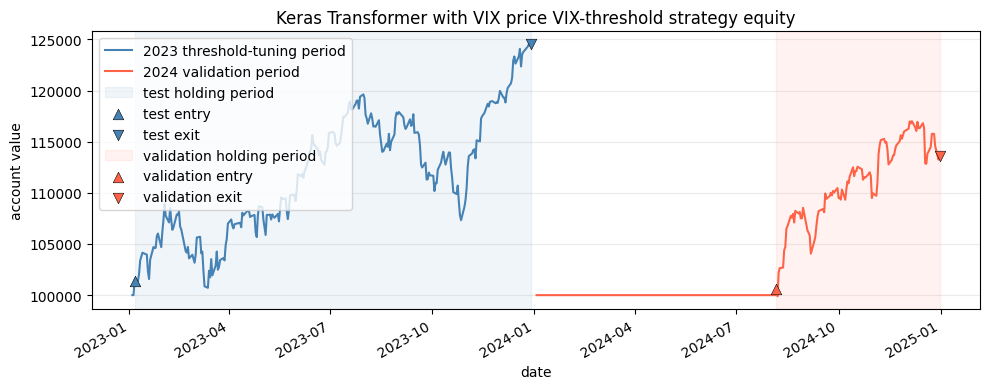

In [27]:
transformer_bt_test = Backtest(spx_test, VixPredStrategy, cash=100_000, commission=0, exclusive_orders=True, finalize_trades=True)

transformer_opt, transformer_heatmap = transformer_bt_test.optimize(
    vix_rise_threshold=[0.005, 0.01, 0.02, 0.03, 0.04, 0.05],
    vix_fall_threshold=[-0.05, -0.04, -0.03, -0.02, -0.01, -0.005],
    maximize="Sharpe Ratio",
    constraint=lambda p: p.vix_fall_threshold < p.vix_rise_threshold,
    return_heatmap=True,
)

transformer_best_rise = transformer_opt._strategy.vix_rise_threshold
transformer_best_fall = transformer_opt._strategy.vix_fall_threshold

transformer_bt_val = Backtest(spx_val, VixPredStrategy, cash=100_000, commission=0, exclusive_orders=True, finalize_trades=True)
transformer_val_results = transformer_bt_val.run(
    vix_rise_threshold=transformer_best_rise,
    vix_fall_threshold=transformer_best_fall,
)

backtest_metrics = ["Buy & Hold Return [%]", "Return [%]", "Max. Drawdown [%]", "Sharpe Ratio", "# Trades"]
print("Test results")
print(transformer_opt[backtest_metrics])
print("\nValidation results")
print(transformer_val_results[backtest_metrics])
print(f"\nBest thresholds from 2023: rise={transformer_best_rise}, fall={transformer_best_fall}")

plot_backtest_equity(transformer_opt, transformer_val_results, MODEL_LABEL)
transformer_bt_val.plot(plot_equity=False, plot_volume=False, plot_return=False);
